In [38]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBRegressor

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

from mlflow import MlflowClient

from dotenv import load_dotenv
import sys

import matplotlib.pyplot as plt

ROOT_DIR = Path.cwd().parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.paths import DATA_RAW_PATH, DATA_OUTPUTS_PATH

In [2]:
MLFLOW_REMOTE_URI = "https://stoneray-mlflow-getaround.hf.space"
mlflow.set_tracking_uri(MLFLOW_REMOTE_URI)

mlflow.set_experiment("Getaround Pricing")

<Experiment: artifact_location='s3://mlflow-getaround-2026/artifact_store/1', creation_time=1781791425658, experiment_id='1', last_update_time=1781791425658, lifecycle_stage='active', name='Getaround Pricing', tags={}>

In [3]:
mlflow.search_experiments()

[<Experiment: artifact_location='s3://mlflow-getaround-2026/artifact_store/1', creation_time=1781791425658, experiment_id='1', last_update_time=1781791425658, lifecycle_stage='active', name='Getaround Pricing', tags={}>,
 <Experiment: artifact_location='s3://mlflow-getaround-2026/artifact_store/0', creation_time=1781790687951, experiment_id='0', last_update_time=1781790687951, lifecycle_stage='active', name='Default', tags={}>]

In [4]:
df = pd.read_csv(DATA_OUTPUTS_PATH / "pricing_data.csv", index_col=0)

df.head()

,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,Citroën,140411.0,100.0,diesel,black,convertible,True,True,False,False,True,True,True,106.0
1,Citroën,13929.0,317.0,petrol,grey,convertible,True,True,False,False,False,True,True,264.0
2,Citroën,183297.0,120.0,diesel,white,convertible,False,False,False,False,True,False,True,101.0
3,Citroën,128035.0,135.0,diesel,red,convertible,True,True,False,False,True,True,True,158.0
4,Citroën,97097.0,160.0,diesel,silver,convertible,True,True,False,False,False,True,True,183.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4831 entries, 0 to 4842
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   model_key                  4831 non-null   object 
 1   mileage                    4831 non-null   float64
 2   engine_power               4831 non-null   float64
 3   fuel                       4831 non-null   object 
 4   paint_color                4831 non-null   object 
 5   car_type                   4831 non-null   object 
 6   private_parking_available  4831 non-null   bool   
 7   has_gps                    4831 non-null   bool   
 8   has_air_conditioning       4831 non-null   bool   
 9   automatic_car              4831 non-null   bool   
 10  has_getaround_connect      4831 non-null   bool   
 11  has_speed_regulator        4831 non-null   bool   
 12  winter_tires               4831 non-null   bool   
 13  rental_price_per_day       4831 non-null   float64
dt

In [6]:
TARGET = "rental_price_per_day"

X = df.drop(columns=[TARGET])
y = df[TARGET]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
numeric_features = X.select_dtypes(include=["int64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: []
Categorical: ['model_key', 'fuel', 'paint_color', 'car_type', 'private_parking_available', 'has_gps', 'has_air_conditioning', 'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']


In [9]:
numeric_transformer = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [10]:
models = {
    "LinearRegression": LinearRegression(),

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

In [ ]:
results = []

for model_name, model in models.items():

    with mlflow.start_run(run_name=model_name):

        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model)
            ]
        )

        # Train
        pipeline.fit(
            X_train,
            y_train
        )

        # Test predictions
        predictions = pipeline.predict(
            X_test
        )

        # Metrics
        mae = mean_absolute_error(
            y_test,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        r2 = r2_score(
            y_test,
            predictions
        )

        # MLflow logging
        mlflow.log_param(
            "model_type",
            model_name
        )

        mlflow.log_metric(
            "MAE",
            mae
        )

        mlflow.log_metric(
            "RMSE",
            rmse
        )

        mlflow.log_metric(
            "R2",
            r2
        )

        # Signature + example
        sample_input = X_train.head(10)

        sample_predictions = pipeline.predict(
            sample_input
        )

        signature = infer_signature(
            sample_input,
            sample_predictions
        )

        mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            signature=signature,
            input_example=X_train.head(5)
        )

        # Store results
        results.append(
            {
                "Model": model_name,
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2
            }
        )

        print(
            f"{model_name} | "
            f"MAE={mae:.2f} | "
            f"RMSE={rmse:.2f} | "
            f"R²={r2:.4f}"
        )

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="RMSE",
    ascending=True
)

LinearRegression | MAE=17.53 | RMSE=24.95 | R²=0.4702
🏃 View run LinearRegression at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/c231a49b3ff8440c94a40eb8ae49369c
🧪 View experiment at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1
RandomForest | MAE=16.69 | RMSE=24.51 | R²=0.4887
🏃 View run RandomForest at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/eb893f62766541ba83b3487bd98f9d34
🧪 View experiment at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1
GradientBoosting | MAE=16.88 | RMSE=24.16 | R²=0.5034
🏃 View run GradientBoosting at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/8e69fc4edf4f4e3485be7b41c1c8e185
🧪 View experiment at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1
XGBoost | MAE=16.59 | RMSE=24.13 | R²=0.5044
🏃 View run XGBoost at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/2a5af75b2db64c78b3c3d22c62a6dad0
🧪 View experiment at: https://stoneray-mlflow-getar

,Model,MAE,RMSE,R2
3,XGBoost,16.590489,24.132879,0.504359
2,GradientBoosting,16.880604,24.157153,0.503362
1,RandomForest,16.686105,24.509958,0.488749
0,LinearRegression,17.534399,24.949825,0.470235


## Model enhancing (TOP 2)

In [ ]:

# Hyperparameter grids


param_grids = {

    "XGBoost": {
        "model__n_estimators": [100, 300, 500],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
        "model__min_child_weight": [1, 3, 5],
        "model__gamma": [0, 0.1, 0.3]
    },

    "GradientBoosting": {
        "model__n_estimators": [100, 200, 400],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 4, 6],
        "model__subsample": [0.7, 0.8, 1.0]
    }
}


# Keep only top models


models_to_tune = {
    "XGBoost": models["XGBoost"],
    "GradientBoosting": models["GradientBoosting"]
}


# MLflow


mlflow.sklearn.autolog(log_models=False)

results = []


# Hyperparameter tuning


for model_name, model in models_to_tune.items():

    with mlflow.start_run(run_name=f"Tune_{model_name}"):

        print(f"\nOptimizing {model_name}")

        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model)
            ]
        )

        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grids[model_name],
            n_iter=50,
            cv=5,
            scoring="neg_root_mean_squared_error",
            random_state=42,
            n_jobs=-1,
            verbose=2
        )

        search.fit(X_train, y_train)

        best_pipeline = search.best_estimator_

        predictions = best_pipeline.predict(X_test)

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        r2 = r2_score(
            y_test,
            predictions
        )

        # Best parameters
        for param_name, param_value in search.best_params_.items():
            mlflow.log_param(
                param_name,
                param_value
            )

        # Metrics
        mlflow.log_metric(
            "CV_RMSE",
            abs(search.best_score_)
        )

        mlflow.log_metric(
            "MAE",
            mae
        )

        mlflow.log_metric(
            "RMSE",
            rmse
        )

        mlflow.log_metric(
            "R2",
            r2
        )

        # Signature
        sample_input = X_train.head(10)

        signature = infer_signature(
            sample_input,
            best_pipeline.predict(sample_input)
        )

        mlflow.sklearn.log_model(
            sk_model=best_pipeline,
            artifact_path="best_model",
            signature=signature,
            input_example=X_train.head(5)
        )

        results.append(
            {
                "Model": f"{model_name} Tuned",
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2
            }
        )

        print("\nBest Parameters")
        print(search.best_params_)

        print(
            f"MAE={mae:.2f} | "
            f"RMSE={rmse:.2f} | "
            f"R2={r2:.4f}"
        )


# Stop autologging


mlflow.sklearn.autolog(disable=True)


# Final ranking


tuned_df = (
    pd.DataFrame(results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

display(tuned_df)



🚀 Optimizing XGBoost
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END model__colsample_bytree=0.8, model__gamma=0.3, model__learning_rate=0.05, model__max_depth=3, model__min_child_weight=5, model__n_estimators=100, model__subsample=1.0; total time=   0.0s
[CV] END model__colsample_bytree=0.8, model__gamma=0.3, model__learning_rate=0.05, model__max_depth=3, model__min_child_weight=5, model__n_estimators=100, model__subsample=1.0; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__gamma=0.3, model__learning_rate=0.05, model__max_depth=3, model__min_child_weight=5, model__n_estimators=100, model__subsample=1.0; total time=   0.0s
[CV] END model__colsample_bytree=1.0, model__gamma=0.1, model__learning_rate=0.05, model__max_depth=7, model__min_child_weight=3, model__n_estimators=100, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=1.0, model__gamma=0.1, model__learning_rate=0.05, model__max_depth=7, model__min_child_weight=3, mo

2026/06/18 16:55:26 INFO mlflow.sklearn.utils: Logging the 5 best runs, 45 runs will be omitted.


🏃 View run crawling-roo-992 at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/65196622eaec4405a4abfbde6fbc6079
🧪 View experiment at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1
🏃 View run delicate-crab-584 at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/15f29f95d7784e768d63bcbf4d708bf6
🧪 View experiment at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1
🏃 View run funny-hawk-904 at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/9920812dd706448f90c7fef63fc90e4c
🧪 View experiment at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1
🏃 View run abundant-goat-44 at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/28da8e20f22c4f41a76373740bd2b4ce
🧪 View experiment at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1
🏃 View run luminous-steed-156 at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/4ba5a6bc28be4e0c9a03140c4acf1368
🧪 View experiment at: https://

2026/06/18 16:55:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Best Parameters
{'model__subsample': 0.8, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__gamma': 0.1, 'model__colsample_bytree': 1.0}
MAE=16.68 | RMSE=23.92 | R2=0.5130
🏃 View run Tune_XGBoost at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/b2dd738c035b443b9d80382786ecaf80
🧪 View experiment at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1

🚀 Optimizing GradientBoosting
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.7; total time=   0.3s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.7; total time=   0.3s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.7; total time=   0.3s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=200, model__subsa

2026/06/18 16:55:59 INFO mlflow.sklearn.utils: Logging the 5 best runs, 45 runs will be omitted.


🏃 View run auspicious-asp-152 at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/dcc04953754e4373aa4c6557cf4ff256
🧪 View experiment at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1
🏃 View run valuable-ant-715 at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/392d1bc4708c4130948d5959fdfe0273
🧪 View experiment at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1
🏃 View run traveling-snail-711 at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/8c532f7eaae84e2a863bfe62195d7206
🧪 View experiment at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1
🏃 View run beautiful-yak-7 at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/1703df41fc914845b734a2d361ae8423
🧪 View experiment at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1
🏃 View run treasured-sponge-572 at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/6cbe3cb97e9840a2b7df5d2596ba7fa3
🧪 View experiment at: h

2026/06/18 16:56:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Best Parameters
{'model__subsample': 1.0, 'model__n_estimators': 400, 'model__max_depth': 4, 'model__learning_rate': 0.05}
MAE=16.96 | RMSE=23.92 | R2=0.5133
🏃 View run Tune_GradientBoosting at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1/runs/259dd99c4de047cdab9ea61d1e817e28
🧪 View experiment at: https://stoneray-mlflow-getaround.hf.space/#/experiments/1


,Model,MAE,RMSE,R2
0,GradientBoosting Tuned,16.955718,23.915061,0.513266
1,XGBoost Tuned,16.681000,23.921008,0.513024


In [18]:
display(results_df)

,Model,MAE,RMSE,R2
0,LinearRegression,17.534399,24.949825,0.470235
1,RandomForest,16.686105,24.509958,0.488749
2,GradientBoosting,16.880604,24.157153,0.503362
3,XGBoost,16.590489,24.132879,0.504359


### Choosing best model

In [19]:
runs = mlflow.search_runs(
    experiment_names=["Getaround Pricing"]
)

runs.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.std_fit_time,metrics.mean_score_time,metrics.mean_fit_time,metrics.mean_test_score,...,params.best_model__gamma,params.model_type,tags.mlflow.parentRunId,tags.estimator_name,tags.mlflow.user,tags.estimator_class,tags.mlflow.source.name,tags.mlflow.autologging,tags.mlflow.runName,tags.mlflow.source.type
0,1703df41fc914845b734a2d361ae8423,1,FINISHED,s3://mlflow-getaround-2026/artifact_store/1/17...,2026-06-18 14:55:35.625000+00:00,2026-06-18 14:55:59.865000+00:00,0.068754,0.025187,1.823119,-22.630641,...,None,None,259dd99c4de047cdab9ea61d1e817e28,Pipeline,manjakaranjatoson,sklearn.pipeline.Pipeline,/Users/manjakaranjatoson/Desktop/A_I/JEDHA/PRO...,sklearn,beautiful-yak-7,LOCAL
1,259dd99c4de047cdab9ea61d1e817e28,1,FINISHED,s3://mlflow-getaround-2026/artifact_store/1/25...,2026-06-18 14:55:35.625000+00:00,2026-06-18 14:56:08.381000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,RandomizedSearchCV,manjakaranjatoson,sklearn.model_selection._search.RandomizedSear...,/Users/manjakaranjatoson/Desktop/A_I/JEDHA/PRO...,None,Tune_GradientBoosting,LOCAL
2,392d1bc4708c4130948d5959fdfe0273,1,FINISHED,s3://mlflow-getaround-2026/artifact_store/1/39...,2026-06-18 14:55:35.625000+00:00,2026-06-18 14:55:59.865000+00:00,0.015351,0.012529,0.904053,-22.591117,...,None,None,259dd99c4de047cdab9ea61d1e817e28,Pipeline,manjakaranjatoson,sklearn.pipeline.Pipeline,/Users/manjakaranjatoson/Desktop/A_I/JEDHA/PRO...,sklearn,valuable-ant-715,LOCAL
3,6cbe3cb97e9840a2b7df5d2596ba7fa3,1,FINISHED,s3://mlflow-getaround-2026/artifact_store/1/6c...,2026-06-18 14:55:35.625000+00:00,2026-06-18 14:55:59.865000+00:00,0.087050,0.013757,0.655845,-22.649513,...,None,None,259dd99c4de047cdab9ea61d1e817e28,Pipeline,manjakaranjatoson,sklearn.pipeline.Pipeline,/Users/manjakaranjatoson/Desktop/A_I/JEDHA/PRO...,sklearn,treasured-sponge-572,LOCAL
4,8c532f7eaae84e2a863bfe62195d7206,1,FINISHED,s3://mlflow-getaround-2026/artifact_store/1/8c...,2026-06-18 14:55:35.625000+00:00,2026-06-18 14:55:59.865000+00:00,0.021126,0.013195,0.688308,-22.649686,...,None,None,259dd99c4de047cdab9ea61d1e817e28,Pipeline,manjakaranjatoson,sklearn.pipeline.Pipeline,/Users/manjakaranjatoson/Desktop/A_I/JEDHA/PRO...,sklearn,traveling-snail-711,LOCAL


In [27]:
runs = runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "metrics.MAE",
        "metrics.RMSE",
        "metrics.R2"
    ]
].sort_values(ascending=False, by="metrics.R2")

runs.head()

,run_id,tags.mlflow.runName,metrics.MAE,metrics.RMSE,metrics.R2
1,259dd99c4de047cdab9ea61d1e817e28,Tune_GradientBoosting,16.955718,23.915061,0.513266
11,b2dd738c035b443b9d80382786ecaf80,Tune_XGBoost,16.681000,23.921008,0.513024
12,2a5af75b2db64c78b3c3d22c62a6dad0,XGBoost,16.590489,24.132879,0.504359
13,8e69fc4edf4f4e3485be7b41c1c8e185,GradientBoosting,16.880604,24.157153,0.503362
14,eb893f62766541ba83b3487bd98f9d34,RandomForest,16.686105,24.509958,0.488749


In [29]:
best_run = (
    runs.sort_values(
        by="metrics.R2",
        ascending=False
    )
    .iloc[0]
)

best_run

run_id                 259dd99c4de047cdab9ea61d1e817e28
tags.mlflow.runName               Tune_GradientBoosting
metrics.MAE                                   16.955718
metrics.RMSE                                  23.915061
metrics.R2                                     0.513266
Name: 1, dtype: object

Why Tune_GradientBoosting is the Best ChoiceBest Pattern Recognition ($R^2 = 0.5132$): 
* It captures the highest percentage of data variance, meaning it truly understands the logic behind price fluctuations rather than just memorizing easy examples.
* More Trustworthy Accuracy (MAE = 16.95): Prioritizing a high $R^2$ ensures that this average error is stable, robust, and will actually hold up against new, unseen data in production.
* Fewest Extreme Blunders (RMSE = 23.91): Since RMSE heavily penalizes large mistakes, bringing this score below 24 proves this model is the most consistent and least likely to make a catastrophic pricing error.

In [36]:
BEST_RUN_ID = best_run["run_id"]

BEST_MODEL_NAME = best_run[
    "tags.mlflow.runName"
]

print(BEST_MODEL_NAME)
print(BEST_RUN_ID)

Tune_GradientBoosting
259dd99c4de047cdab9ea61d1e817e28


In [32]:
result = mlflow.register_model(
    model_uri=f"runs:/{BEST_RUN_ID}/best_model",
    name="getaround-pricing-model"
)

client = MlflowClient()

client.set_registered_model_alias(
    name="getaround-pricing-model",
    alias="champion",
    version=result.version
)

client.get_model_version_by_alias(
    "getaround-pricing-model",
    "champion"
)

Successfully registered model 'getaround-pricing-model'.
2026/06/18 17:24:25 WARNING mlflow.tracking._model_registry.fluent: Run with id 259dd99c4de047cdab9ea61d1e817e28 has no artifacts at artifact path 'best_model', registering model based on models:/m-220940a590904135a6e58753b7c0f436 instead
2026/06/18 17:24:25 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: getaround-pricing-model, version 1
Created version '1' of model 'getaround-pricing-model'.


<ModelVersion: aliases=['champion'], creation_timestamp=1781796265436, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1781796265436, metrics=None, model_id=None, name='getaround-pricing-model', params=None, run_id='259dd99c4de047cdab9ea61d1e817e28', run_link='', source='models:/m-220940a590904135a6e58753b7c0f436', status='READY', status_message=None, tags={}, user_id='', version='1'>

### The most important features of Champion model

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract model and feature names
model = best_pipeline.named_steps["model"]

feature_names = (
    best_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Raw importances
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

# Aggregate OHE columns back to original features
aggregated_importance = []

for feature in X.columns:

    total_importance = importance_df.loc[
        importance_df["feature"].str.contains(feature, regex=False),
        "importance"
    ].sum()

    aggregated_importance.append({
        "feature": feature,
        "importance": total_importance
    })

aggregated_importance = (
    pd.DataFrame(aggregated_importance)
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(aggregated_importance)

,feature,importance
0,model_key,0.276978
1,automatic_car,0.265501
2,car_type,0.120530
3,has_getaround_connect,0.105701
4,has_gps,0.069002
5,paint_color,0.054468
6,winter_tires,0.027048
7,has_speed_regulator,0.026501
8,private_parking_available,0.020610
9,fuel,0.020111


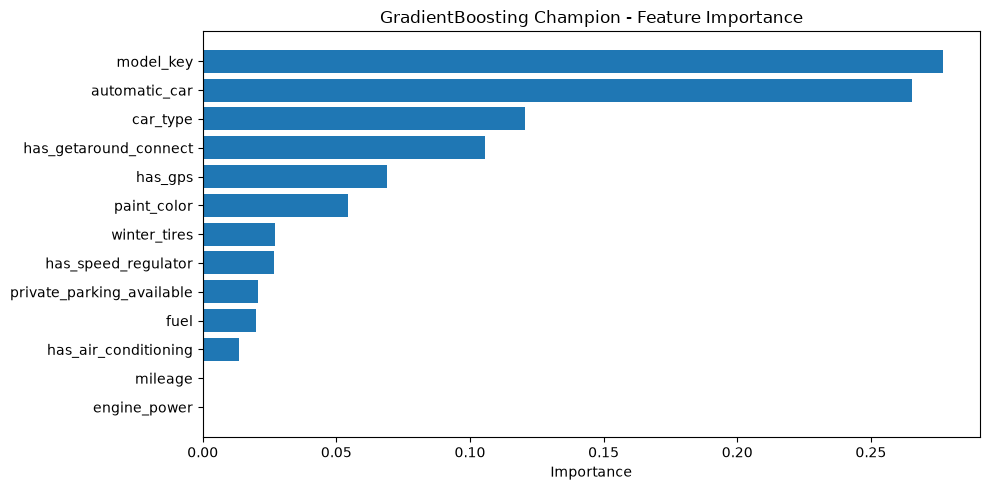

In [41]:
# Plot
plt.figure(figsize=(10, 5))

plt.barh(
    aggregated_importance["feature"][::-1],
    aggregated_importance["importance"][::-1]
)

plt.title("GradientBoosting Champion - Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [42]:
print(X.columns.to_list())

['model_key', 'mileage', 'engine_power', 'fuel', 'paint_color', 'car_type', 'private_parking_available', 'has_gps', 'has_air_conditioning', 'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']


### Object features unique values

In [43]:
categorical_features = [
    "model_key",
    "fuel",
    "paint_color",
    "car_type"
]

for col in categorical_features:
    print(f"\n{col}")
    print(sorted(df[col].dropna().unique()))


model_key
['Alfa Romeo', 'Audi', 'BMW', 'Citroën', 'Ferrari', 'Fiat', 'Ford', 'Honda', 'KIA Motors', 'Lamborghini', 'Lexus', 'Maserati', 'Mazda', 'Mercedes', 'Mitsubishi', 'Nissan', 'Opel', 'PGO', 'Peugeot', 'Porsche', 'Renault', 'SEAT', 'Subaru', 'Suzuki', 'Toyota', 'Volkswagen', 'Yamaha']

fuel
['diesel', 'electro', 'hybrid_petrol', 'petrol']

paint_color
['beige', 'black', 'blue', 'brown', 'green', 'grey', 'orange', 'red', 'silver', 'white']

car_type
['convertible', 'coupe', 'estate', 'hatchback', 'sedan', 'subcompact', 'suv', 'van']
